In [27]:
# Cell 1: Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings

# Bỏ qua các cảnh báo không quan trọng của thư viện vẽ biểu đồ
warnings.filterwarnings('ignore')

In [28]:
# Cell 2: Configurations
INPUT_FILE = "data_dongmai_all_raw.csv"

# Thiết lập phong cách biểu đồ chuẩn học thuật (nền trắng lưới xám)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [29]:
# Cell 3: Core Functions

def show_summary_statistics(df, column_name):
    """Tính toán và in ra màn hình các chỉ số thống kê cơ bản."""
    print(f"--- THỐNG KÊ CƠ BẢN CHO: {column_name.upper()} ---")
    stats = df[column_name].describe()
    print(f"Tổng số dòng dữ liệu: {int(stats['count'])} giờ")
    print(f"Giá trị nhỏ nhất (Min): {stats['min']:.2f} µg/m³")
    print(f"Giá trị lớn nhất (Max): {stats['max']:.2f} µg/m³")
    print(f"Giá trị trung bình (Mean): {stats['mean']:.2f} µg/m³")
    print("-" * 50)

def plot_hourly_trend(df):
    """Vẽ biểu đồ đường: Xu hướng nồng độ PM2.5 trung bình theo từng giờ."""
    hourly_avg = df.groupby('hour')['pm2_5'].mean().reset_index()
    
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=hourly_avg, x='hour', y='pm2_5', marker='o', color='#2b5c8f')
    
    # Lưu ý: Theo chuẩn trường, tên hình vẽ để dưới ảnh trong file Word, 
    # nên ở đây ta chỉ dùng Title để dễ nhìn trên Jupyter.
    plt.title('Xu hướng nồng độ PM2.5 trung bình theo giờ tại KCN Đông Mai', fontsize=14, pad=15)
    plt.xlabel('Giờ trong ngày (0-23)', fontsize=12)
    plt.ylabel('Nồng độ PM2.5 (µg/m³)', fontsize=12)
    plt.xticks(range(0, 24))
    plt.tight_layout()
    # plt.savefig('01_pm25_hourly_trend.png', dpi=300) # Xuất ảnh nét cao (300 dpi)
    plt.show()

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns # Sử dụng Seaborn để mượn style màu sắc chuẩn mực hơn

def plot_health_impact_high_res(df):
    """
    Vẽ biểu đồ tròn chất lượng cao: Tỷ lệ các cấp độ ảnh hưởng sức khỏe.
    """
    # 1. Cấu hình độ phân giải (Resolution) và Phong cách (Style)
    plt.style.use('seaborn-v0_8-whitegrid') 
    
    bins = [-1, 12.0, 35.4, 55.4, 150.4, 250.4]  
    labels = ['TỐT', 'TRUNG BÌNH', 'KÉM', 'XẤU', 'RẤT XẤU / NGUY HẠI']
    colors = ['#00e400', '#ffff00', '#ff7e00', '#ff0000', '#8f3f97']
    
    df['health_category'] = pd.cut(df['pm2_5'], bins=bins, labels=labels)
    category_counts = df['health_category'].value_counts(sort=False)
    
    # Lọc bỏ các nhãn 0%
    category_counts = category_counts[category_counts > 0]
    active_labels = category_counts.index.tolist()
    active_colors = [colors[labels.index(lbl)] for lbl in active_labels]
    
    # 2. Tạo hiệu ứng tách lát cắt (Explode) cho thành phần chiếm tỷ trọng lớn nhất
    explode = [0.06 if val == category_counts.max() else 0 for val in category_counts]
    
    # Khởi tạo Figure với DPI = 300 (Chuẩn in ấn học thuật)
    fig, ax = plt.subplots(figsize=(9, 9), dpi=300)
    
    # Vẽ biểu đồ với các tinh chỉnh thẩm mỹ
    wedges, texts, autotexts = ax.pie(
        category_counts, 
        labels=active_labels, 
        colors=active_colors, 
        autopct='%1.1f%%', 
        startangle=140,
        explode=explode, 
        shadow=False, # Tắt bóng đổ để giữ phong cách Flat Design hiện đại
        wedgeprops={'edgecolor': 'black', 'linewidth': 1.5, 'antialiased': True} # Bo viền sắc nét
    )
    
    # 3. Tinh chỉnh Typography (Nghệ thuật chữ)
    plt.setp(texts, size=12, weight='bold', color='#333333') # Nhãn phân loại
    plt.setp(autotexts, size=13, weight='bold', color='black') # Con số phần trăm
    
    # Tiêu đề biểu đồ
    ax.set_title('Tỷ Lệ Phân Bố Các Cấp Độ Ảnh Hưởng Sức Khỏe Của PM2.5', 
                 fontsize=23, weight='bold', pad=25, color='#111111')
    
    plt.tight_layout()
    
    # 4. Lưu ảnh đúng chuẩn: Giữ DPI 300 và không bị cắt lề
    plt.savefig('02_pm25_health_impact_high_res.png', dpi=300, format='png', bbox_inches='tight')
    
    plt.show()

def plot_correlation_heatmap(df):
    """Vẽ Bản đồ nhiệt: Tương quan giữa PM2.5 và 5 biến thời tiết."""
    numerical_cols = ['pm2_5', 'temperature_2m', 'relative_humidity_2m', 
                      'wind_speed_10m', 'wind_direction_10m', 'precipitation']
    df_numeric = df[numerical_cols]
    corr_matrix = df_numeric.corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
    plt.title('Ma trận tương quan giữa PM2.5 và các yếu tố khí tượng', fontsize=14, pad=15)
    plt.tight_layout()
    # plt.savefig('03_pm25_correlation_heatmap.png', dpi=300)
    plt.show()

def plot_monthly_seasonality(df):
    """Vẽ biểu đồ Hộp: Phân bố nồng độ PM2.5 theo từng tháng trong năm."""
    month_names = {1: 'Th1', 2: 'Th2', 3: 'Th3', 4: 'Th4', 5: 'Th5', 6: 'Th6', 
                   7: 'Th7', 8: 'Th8', 9: 'Th9', 10: 'Th10', 11: 'Th11', 12: 'Th12'}
    df['month_name'] = df['month'].map(month_names)
    
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x='month', y='pm2_5', palette='viridis')
    plt.title('Phân bố nồng độ PM2.5 theo từng tháng trong năm', fontsize=14, pad=15)
    plt.xlabel('Tháng', fontsize=12)
    plt.ylabel('Nồng độ PM2.5 (µg/m³)', fontsize=12)
    plt.xticks(range(0, 12), [f'Th{i}' for i in range(1, 13)]) # Hiển thị Th1 -> Th12
    plt.tight_layout()
    # plt.savefig('04_pm25_monthly_boxplot.png', dpi=300)
    plt.show()

In [30]:
import pandas as pd
import numpy as np

def convert_pm25_to_vn_aqi(pm25_value):
    """
    Thuật toán nội suy chuyển đổi nồng độ bụi PM2.5 sang điểm số VN_AQI.
    Dựa theo Hướng dẫn kỹ thuật tính toán VN_AQI (Quyết định 1459/QĐ-TCMT).
    """
    if pd.isna(pm25_value): return np.nan
    
    # Cấu trúc Breakpoints: (C_low, C_high, I_low, I_high)
    # C: Nồng độ bụi (Concentration), I: Điểm AQI (Index)
    breakpoints = [
        (0.0, 12.0, 0, 50),        # TỐT
        (12.1, 35.4, 51, 100),     # TRUNG BÌNH
        (35.5, 55.4, 101, 150),    # KÉM
        (55.5, 150.4, 151, 200),   # XẤU
        (150.5, 250.4, 201, 300),  # RẤT XẤU
        (250.5, 350.4, 301, 400),  # NGUY HẠI
        (350.5, 500.4, 401, 500)   # NGUY HẠI (Kịch khung)
    ]
    
    # Làm tròn nồng độ PM2.5 tới 1 chữ số thập phân theo quy chuẩn
    pm25 = round(pm25_value, 1)
    
    # Tìm khoảng giá trị (range) phù hợp và tính nội suy
    for c_low, c_high, i_low, i_high in breakpoints:
        if c_low <= pm25 <= c_high:
            # Công thức nội suy chuẩn của Tổng cục Môi trường
            aqi = ((i_high - i_low) / (c_high - c_low)) * (pm25 - c_low) + i_low
            return round(aqi)
            
    return 500 # Nếu bụi vượt mức 500.4 thì gán mặc định AQI là 500 (cao nhất)


def export_health_impact_vnaqi(df, pm25_col='pm2_5', file_name='data_vnaqi_export.csv'):
    """
    Hàm tính toán và xuất dữ liệu thống kê mức độ ảnh hưởng của VN_AQI ra file CSV.
    """
    # 1. Tính toán cột điểm VN_AQI từ cột nồng độ bụi
    df['VN_AQI'] = df[pm25_col].apply(convert_pm25_to_vn_aqi)
    
    # 2. Định nghĩa ngưỡng theo bảng chuẩn bạn cung cấp
    # Vì ảnh nhóm chung mức Rất Xấu và Nguy Hại (201 - 300+) nên ta sẽ gộp chung.
    bins = [-1, 50, 100, 150, 200, float('inf')]
    labels = ['TỐT', 'TRUNG BÌNH', 'KÉM', 'XẤU', 'RẤT XẤU / NGUY HẠI']
    
    # 3. Phân loại dữ liệu
    df['Cấp độ'] = pd.cut(df['VN_AQI'], bins=bins, labels=labels)
    
    # 4. Thống kê tần suất
    category_counts = df['Cấp độ'].value_counts(sort=False)
    total_samples = len(df['Cấp độ'].dropna())
    category_percentages = (category_counts / total_samples) * 100
    
    # 5. Gộp DataFrame xuất khẩu
    export_df = pd.DataFrame({
        'Khoảng VN_AQI': ['0 - 50', '51 - 100', '101 - 150', '151 - 200', '201 - 300+'],
        'Chất lượng (Cấp độ)': category_counts.index,
        'Số lượng mẫu': category_counts.values,
        'Tỷ lệ (%)': category_percentages.values.round(2)
    })
    
    # 6. Loại bỏ những cấp độ 0% và xuất file
    export_df = export_df[export_df['Số lượng mẫu'] > 0]
    export_df.to_csv(file_name, index=False, encoding='utf-8-sig')
    
    print(f"✅ Đã xuất dữ liệu theo chuẩn QĐ 1459 thành công ra: {file_name}")
    print(export_df)
    
    return export_df

# Cách gọi:
# df_xuat_excel = export_health_impact_vnaqi(df_cua_ban)

Đang đọc dữ liệu từ file data_dongmai_all_raw.csv...
--- THỐNG KÊ CƠ BẢN CHO: PM2_5 ---
Tổng số dòng dữ liệu: 28464 giờ
Giá trị nhỏ nhất (Min): 0.30 µg/m³
Giá trị lớn nhất (Max): 486.20 µg/m³
Giá trị trung bình (Mean): 28.03 µg/m³
--------------------------------------------------
✅ Đã xuất dữ liệu theo chuẩn QĐ 1459 thành công ra: data_vnaqi_export.csv
  Khoảng VN_AQI Chất lượng (Cấp độ)  Số lượng mẫu  Tỷ lệ (%)
0        0 - 50                 TỐT          4222      14.83
1      51 - 100          TRUNG BÌNH         17884      62.83
2     101 - 150                 KÉM          4255      14.95
3     151 - 200                 XẤU          1932       6.79
4    201 - 300+  RẤT XẤU / NGUY HẠI           171       0.60
1/4. Đang vẽ biểu đồ xu hướng theo giờ...


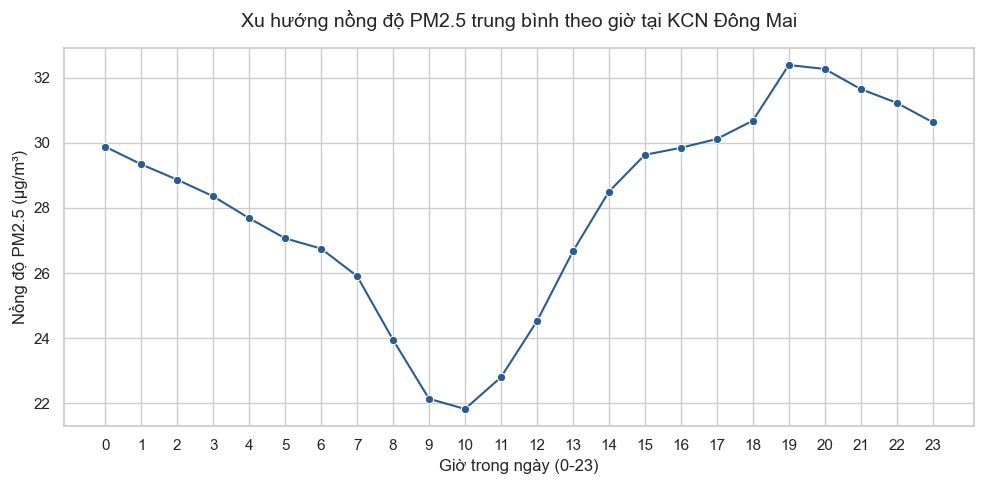

2/4. Đang vẽ biểu đồ mức độ ảnh hưởng sức khỏe...


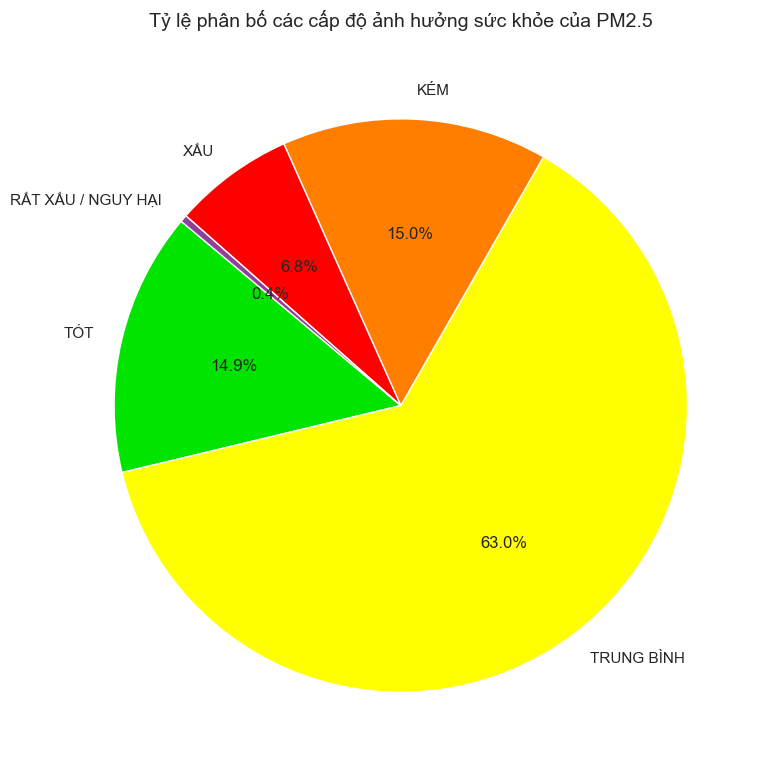

3/4. Đang vẽ biểu đồ ma trận tương quan...


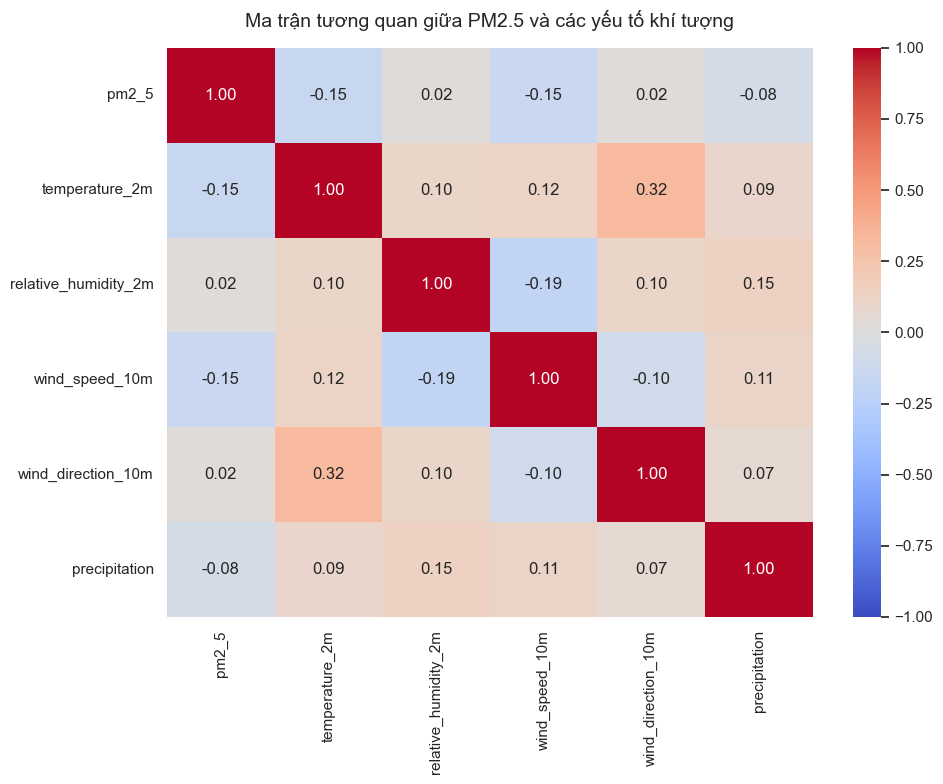

4/4. Đang vẽ biểu đồ chu kỳ theo tháng...


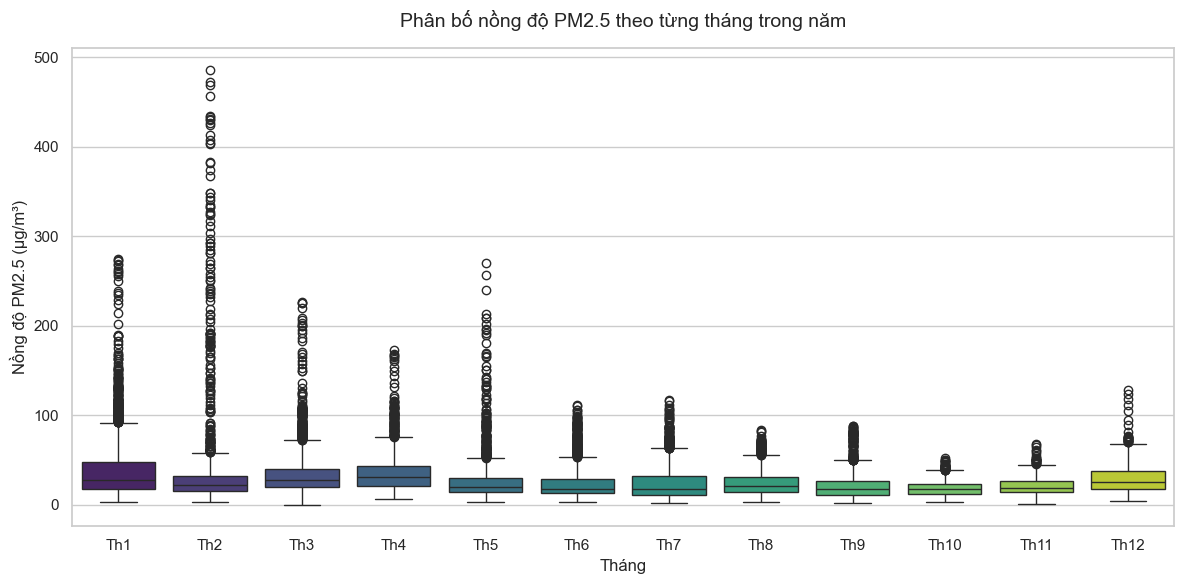


Hoàn tất! Đã xuất 4 file ảnh (đuôi .png) với độ nét cao (300 dpi) vào thư mục làm việc.


In [31]:
# Cell 4: Main Execution
if __name__ == "__main__":
    try:
        print(f"Đang đọc dữ liệu từ file {INPUT_FILE}...")
        df_dongmai = pd.read_csv(INPUT_FILE)
        
        # Tiền xử lý nhẹ để lấy biến thời gian phục vụ vẽ biểu đồ
        df_dongmai['datetime'] = pd.to_datetime(df_dongmai['time'])
        df_dongmai['hour'] = df_dongmai['datetime'].dt.hour
        df_dongmai['month'] = df_dongmai['datetime'].dt.month
        
        # 1. Thống kê cơ bản
        show_summary_statistics(df_dongmai, 'pm2_5')

        df_xuat_excel = export_health_impact_vnaqi(df_dongmai)
        
        # 2. Xu hướng theo giờ
        print("1/4. Đang vẽ biểu đồ xu hướng theo giờ...")
        plot_hourly_trend(df_dongmai)
        
        # 3. Mức độ sức khỏe
        print("2/4. Đang vẽ biểu đồ mức độ ảnh hưởng sức khỏe...")
        plot_health_impact(df_dongmai)
        
        # 4. Tương quan thời tiết
        print("3/4. Đang vẽ biểu đồ ma trận tương quan...")
        plot_correlation_heatmap(df_dongmai)
        
        # 5. Chu kỳ tháng
        print("4/4. Đang vẽ biểu đồ chu kỳ theo tháng...")
        plot_monthly_seasonality(df_dongmai)
        
        print("\nHoàn tất! Đã xuất 4 file ảnh (đuôi .png) với độ nét cao (300 dpi) vào thư mục làm việc.")
        
    except FileNotFoundError:
        print(f"Lỗi: Không tìm thấy file '{INPUT_FILE}'.")
    except Exception as e:
        print(f"Lỗi thực thi: {e}")